## 1. linear Regression
    - using standard scalar

### Importing librarires and pipelines

In [39]:
import sys
sys.path.append(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken")
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [40]:
from src.data_loader import load_data
from src.preprocessing import clean_data
from src.feature_engineering import add_features
from src.pipelines import get_pipeline
from src.evalute import print_scores

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Loading train and test data sets

In [41]:
train_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\train.csv")
test_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\test.csv")

In [42]:
train_df = clean_data(train_df)
test_df = clean_data(test_df)

train_df = add_features(train_df)
test_df = add_features(test_df)

Column 'Time_taken(min)' not found in DataFrame!


### Defining Target feature and other features

In [43]:
target = "Time_taken(min)"

# Drop rows where target is missing
train_df = train_df.dropna(subset=[target])

numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "distance_km",
    "order_to_pickup_time",
    "order_hour",
    "is_weekend"
]

categorical_features = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

X = train_df[numeric_features + categorical_features]
y = train_df[target]

### Train-Test split
- test dataset doesn't have the target feature so i will submit the submission file with the predicted target feature

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Building pipeline with linear regression

In [45]:
model = LinearRegression()
pipeline = get_pipeline(model, numeric_features, categorical_features)

### Training the model

In [46]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'multiple_deliveries',
                                                   'distance_km',
                                                   'order_to_pickup_time',
                                                   'order_hour',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weatherconditions',
                                                   'Road_traffic_density',
                                                   'Type_of_order',
                                                   'Type_of_vehicle',
                                                   'Festival', 'City'])])),
                ('regressor', LinearRegression())])

In [47]:
print_scores(pipeline, X_train, y_train, X_test, y_test)

Train MAE: 5.161768144457134
Test MAE: 5.1465786726544795
Train MSE: 42.935495388921225
Test MSE: 42.96915111559553
Train R2: 0.5129135295342191
Test R2: 0.5099217123134655


### To improve Accuracy -> implementing Ridge Regression

In [48]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
ridge_pipeline = get_pipeline(model, numeric_features, categorical_features)

In [49]:
ridge_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'multiple_deliveries',
                                                   'distance_km',
                                                   'order_to_pickup_time',
                                                   'order_hour',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weatherconditions',
                                                   'Road_traffic_density',
                                                   'Type_of_order',
                                                   'Type_of_vehicle',
                                                   'Festival', 'City'])])),
                ('regressor', Ridge())])

In [50]:
print_scores(ridge_pipeline, X_train, y_train, X_test, y_test)

Train MAE: 5.161786061229359
Test MAE: 5.146685711421031
Train MSE: 42.93551529465134
Test MSE: 42.969977132471854
Train R2: 0.5129133037114649
Test R2: 0.5099122913003471


- using gridsesarchCV to hyperparameter tunning

In [51]:
from sklearn.model_selection import GridSearchCV
import numpy as np

ridge = Ridge()
ridge_pipeline = get_pipeline(ridge, numeric_features, categorical_features)

In [52]:
param_grid = {"regressor__alpha": np.logspace(-3, 3, 100)}  # from 0.001 to 1000

grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_["regressor__alpha"])
print("Best CV Score:", grid.best_score_)

Best alpha: 4.9770235643321135
Best CV Score: 0.5118556054997228


In [53]:
best_model = grid.best_estimator_
print_scores(best_model, X_train, y_train, X_test, y_test)

Train MAE: 5.161872445600303
Test MAE: 5.1471021599477815
Train MSE: 42.93596895553722
Test MSE: 42.9734693716495
Train R2: 0.5129081571054297
Test R2: 0.5098724610837395


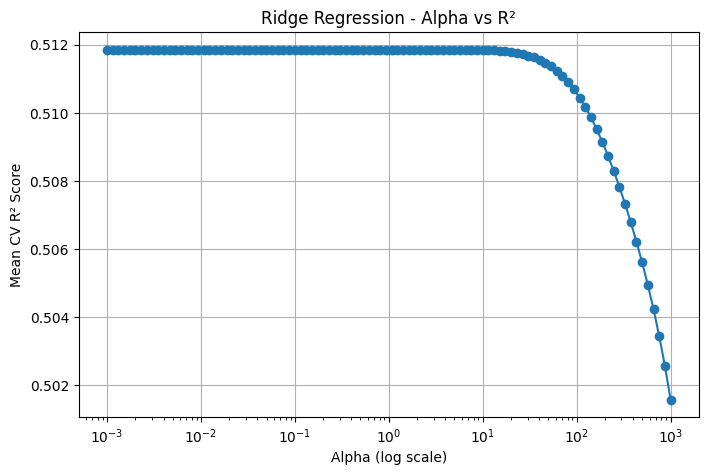

In [54]:
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8,5))
plt.semilogx(results["param_regressor__alpha"], results["mean_test_score"], marker="o")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV R² Score")
plt.title("Ridge Regression - Alpha vs R²")
plt.grid(True)
plt.show()

- No improvement in accuaracy -> applying lasso

In [55]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)
lasso_pipeline = get_pipeline(model, numeric_features, categorical_features)

In [56]:
lasso_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'multiple_deliveries',
                                                   'distance_km',
                                                   'order_to_pickup_time',
                                                   'order_hour',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weatherconditions',
                                                   'Road_traffic_density',
                                                   'Type_of_order',
                                                   'Type_of_vehicle',
                                                   'Festival', 'City'])])),
                ('regressor', Lasso(alpha=0.1))])

In [57]:
print_scores(lasso_pipeline, X_train, y_train, X_test, y_test)

Train MAE: 5.224055347105043
Test MAE: 5.210475371734233
Train MSE: 44.26855007539376
Test MSE: 44.349003165012164
Train R2: 0.4977905433827814
Test R2: 0.49418401417231184


- Hyper parameter tuning using gridsearchCv

In [58]:
lasso = Lasso()
lasso_pipeline = get_pipeline(lasso, numeric_features, categorical_features)


In [59]:
param_grid = {"regressor__alpha": np.logspace(-3, 3, 100)}  # from 0.001 to 1000

grid_lasso = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)
grid_lasso.fit(X_train, y_train)
print("Best alpha:", grid_lasso.best_params_["regressor__alpha"])
print("Best CV Score:", grid_lasso.best_score_)

Best alpha: 0.0023101297000831605
Best CV Score: 0.5119778691563288


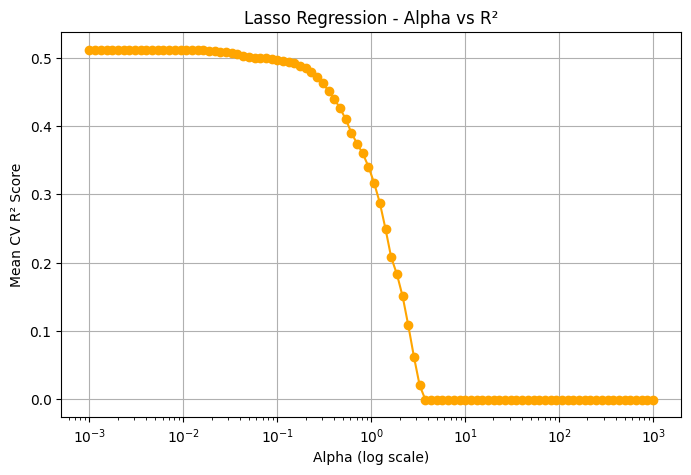

In [60]:
results_lasso = pd.DataFrame(grid_lasso.cv_results_)
plt.figure(figsize=(8,5))
plt.semilogx(results_lasso["param_regressor__alpha"], results_lasso["mean_test_score"], marker="o", color='orange')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV R² Score")
plt.title("Lasso Regression - Alpha vs R²")
plt.grid(True)
plt.show()

### visualizing the regression curve

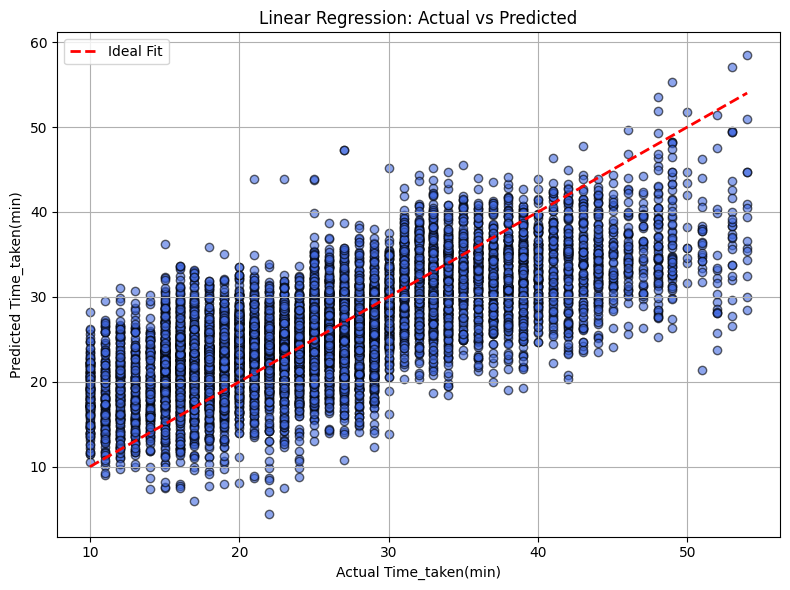

In [61]:
y_pred = best_model.predict(X_test)

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Time_taken(min)')
plt.ylabel('Predicted Time_taken(min)')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()